# SAXS model fit with Porod and factral distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

In [2]:
 # ========== SAXS Model Components ==========
 
def I_aggregate(q, A, exponent):
    """Power-law scattering for aggregates."""
    return A / (q**exponent)
 
def I_DAB(q, delta_SLD, phi_0, xi):
    """Debye-Anderson-Brumberger (DAB) model."""
    theta_squared = (delta_SLD**2) * phi_0 * (1 - phi_0)
    return (8 * np.pi * theta_squared * (1e-7*xi)**3) / ((1 + q**2 * xi**2)**2)
 
def calculate_total_intensity(params, q, _):
    # Unpack parameters
    A, exponent, delta_SLD_1, phi_1, xi1, delta_SLD_2, phi_2, xi2 = params
    I_agg = I_aggregate(q, A, exponent)
    I_pp  = I_DAB(q, delta_SLD_1, phi_1, xi1)
    I_pore = I_DAB(q, delta_SLD_2, phi_2, xi2)
 
    return I_agg + I_pp + I_pore
 
 def chi_squared(params, q, I_exp, Q_min, Q_max, I_err):
    mask = (q >= Q_min) & (q <= Q_max)
    q_sel, I_exp_sel, I_err_sel = q[mask], I_exp[mask], I_err[mask]
 
    I_model = calculate_total_intensity(params, q_sel, I_exp_sel)
    chi2 = np.sum(((np.log(I_exp_sel / I_err_sel) - np.log(I_model / I_err_sel)))**2)
    print("Chi2 =", chi2, "Params =", params)
    return chi2

def check_param_boundaries(opt_params, bounds, tol=1e-3):
    """
    Checks if any optimized parameter is at its lower or upper boundary.
    Returns a list of (index, value, 'lower'/'upper') for each parameter at a boundary.
    """
    hits = []
    for i, (val, (low, high)) in enumerate(zip(opt_params, bounds)):
        if abs(val - low) < tol:
            hits.append((i, val, 'lower'))
        elif abs(val - high) < tol:
            hits.append((i, val, 'upper'))
    return hits

In [3]:
# ========== Load Experimental Data ==========
file_path = r"C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\KJB_powder_with_sulfur\KB_buffer_subtracted.dat"
filename = os.path.basename(file_path).replace(".dat", "")
output_dir = "fitting_results"
os.makedirs(output_dir, exist_ok=True)
 
with open(file_path, 'r') as f:
    lines = f.readlines()
 
swaxs_start = next(i for i, l in enumerate(lines) if l.startswith(" q(A-1)"))+ 6
swaxs_end = next((i for i, l in enumerate(lines[swaxs_start:], start=swaxs_start) if float(l.split()[0]) > 0.4), None)
data = np.loadtxt(file_path, skiprows=swaxs_start, max_rows= swaxs_end - swaxs_start)
 
q_data = data[:, 0] * 10  # Convert to nm^-1
I_data = data[:, 1]
I_err = data[:, 2]

Chi2 = 12284.236451657702 Params = [1.0e-08 3.5e+00 1.0e+11 4.0e-01 5.0e+00 1.0e+11 8.0e-01 1.0e+00]
Chi2 = 12388.53908680943 Params = [3.81966012e-01 3.50000000e+00 1.00000000e+11 4.00000000e-01
 5.00000000e+00 1.00000000e+11 8.00000000e-01 1.00000000e+00]
Chi2 = 12451.752042372249 Params = [6.18033989e-01 3.50000000e+00 1.00000000e+11 4.00000000e-01
 5.00000000e+00 1.00000000e+11 8.00000000e-01 1.00000000e+00]
Chi2 = 12349.005632903423 Params = [2.36067978e-01 3.50000000e+00 1.00000000e+11 4.00000000e-01
 5.00000000e+00 1.00000000e+11 8.00000000e-01 1.00000000e+00]
Chi2 = 12324.38613646364 Params = [1.45898035e-01 3.50000000e+00 1.00000000e+11 4.00000000e-01
 5.00000000e+00 1.00000000e+11 8.00000000e-01 1.00000000e+00]
Chi2 = 12309.096964530363 Params = [9.01699447e-02 3.50000000e+00 1.00000000e+11 4.00000000e-01
 5.00000000e+00 1.00000000e+11 8.00000000e-01 1.00000000e+00]
Chi2 = 12299.619095462538 Params = [5.57280909e-02 3.50000000e+00 1.00000000e+11 4.00000000e-01
 5.00000000e+00

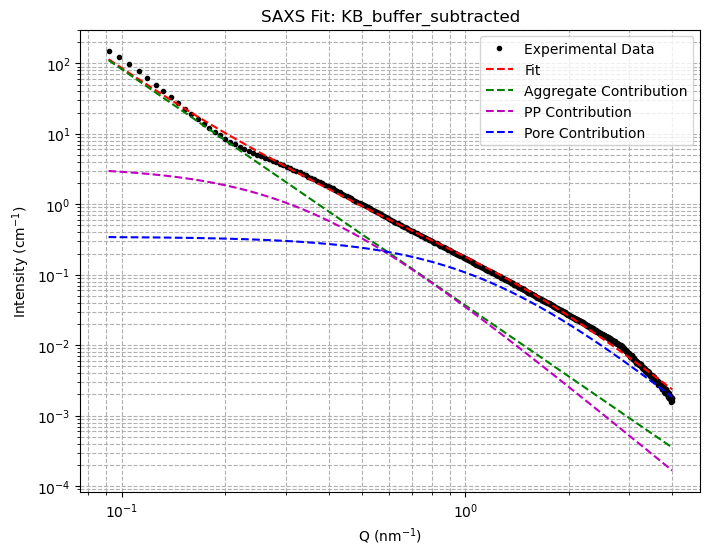

In [4]:
# ========== Fit Parameters ==========
# [A, exponent, delta_SLD_1, phi_1, xi1, delta_SLD_2,  phi_2 xi2]
initial_params = [1e-8, 3.5, 1.0e11, 0.4, 5.0, 1.0e11, 0.8, 1.0]
bounds = [
    (1e-9, 1),       # 0-A
    (1.0, 5.0),      # 1-exponent
    (1e5, 3e11),     # 2-delta_SLD_1
    (0.001, 0.9),    # 3-phi_1
    (1.0, 100.0),    # 4-xi1
    (1e10, 3e11),    # 5-delta_SLD_2
    (0.1, 0.9),      # 6-phi_2
    (0.5, 5.0)       # 7-xi2
]
Qmin, Qmax = 0.1, 4   # Range in nm^-1 for fitting 
 
# ========== Perform Optimization ==========
result = minimize(chi_squared, initial_params, args=(q_data, I_data, Qmin, Qmax, I_err), bounds=bounds, method='Powell')
opt_params = result.x

boundary_hits = check_param_boundaries(opt_params, bounds)
if boundary_hits:
    print("\nWarning: Some parameters hit their boundaries:")
    for idx, val, which in boundary_hits:
        print(f"Param {idx} = {val:.4e} at {which} boundary\n")
else:
    print("No parameters at boundaries\n.")
 
# ========== Plot Results ==========
I_fit = calculate_total_intensity(opt_params, q_data, I_data)
I_fit_pore = I_DAB(q_data, opt_params[5], 1.0 - opt_params[6], opt_params[7])
I_fit_agg = I_aggregate(q_data, opt_params[0], opt_params[1])
I_fit_pp = I_DAB(q_data, opt_params[2], opt_params[3], opt_params[4])

print('Optimized Parameters:\n',
    f"A= {opt_params[0]:.4e},\n"
    f"exponent= {opt_params[1]:.4e},\n"
    f"delta_SLD_1= {opt_params[2]:.4e},\n"
    f"phi_1= {opt_params[3]:.4e},\n"
    f"xi1= {opt_params[4]:.4e},\n"
    f"delta_SLD_2= {opt_params[5]:.4e},\n"
    f"phi_2= {opt_params[6]:.4e},\n"
    f"xi2= {opt_params[7]:.4e}"
)
plt.figure(figsize=(8, 6))

plt.loglog(q_data, I_data, 'k.', label='Experimental Data')
plt.loglog(q_data, I_fit, 'r--', label='Fit')
plt.loglog(q_data, I_fit_agg, 'g--', label='Aggregate Contribution')
plt.loglog(q_data, I_fit_pp, 'm--', label='PP Contribution')
plt.loglog(q_data, I_fit_pore, 'b--', label='Pore Contribution')

plt.xlabel("Q (nm$^{-1}$)")
plt.ylabel("Intensity (cm$^{-1}$)")
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.title(f"SAXS Fit: {filename}")
plt.show()

In [ ]:
from ipywidgets import interact, FloatSlider, VBox, Button

import matplotlib.pyplot as plt

# Define a function to simulate and plot with user-modified parameters
def simulate_and_plot(A=opt_params[0], exponent=opt_params[1], delta_SLD_1=opt_params[2], 
                     phi_1=opt_params[3], xi1=opt_params[4], delta_SLD_2=opt_params[5], phi_2=opt_params[6], xi2=opt_params[7]):
    # Simulated curve with user parameters
    I_sim = I_aggregate(q_data, A, exponent) + \
            I_DAB(q_data, delta_SLD_1, phi_1, xi1) + \
            I_DAB(q_data, delta_SLD_2, phi_2, xi2)
    # Plot
    fntsize = 26
    plt.rcParams.update({'font.size': fntsize})
    plt.figure(figsize=(7, 5.8))
    plt.loglog(q_data, I_data, 'k.', alpha=0.2, label='KB powder', markersize=16, markerfacecolor='none')
    skip = 4  # Change this value to skip more or fewer points
    # plt.loglog(q_data[::skip], calculate_total_intensity(opt_params, q_data, I_data)[::skip], 'ro', markerfacecolor='none', label='Optimized Fit', alpha=0.5)
    plt.loglog(q_data, calculate_total_intensity(opt_params, q_data, I_data), 'r--', label='model fit', alpha=0.7, linewidth=2)
    plt.loglog(q_data, I_sim, color='navy', label='simulated sulfur infiltration', linewidth=2)
    plt.xlim(0.1, 4)
    plt.xlabel("q (nm$^{-1}$)")
    plt.ylabel("Intensity (cm$^{-1}$)")
    plt.legend(frameon=False, fontsize=16)
    plt.xticks([0.2, 0.5, 1.0, 3.0], ['0.2', '0.5', '1.0', '3.0'], fontsize=fntsize)
    #plt.grid(True, which='both', linestyle='--')
    #plt.title(f"SAXS Fit Overlay: {filename}")

    plt.show()

# Interactive sliders for each parameter
interact(
    simulate_and_plot,
    A=FloatSlider(min=bounds[0][0], max=bounds[0][1], step=(bounds[0][1]-bounds[0][0])/100, value=opt_params[0], description='A'),
    exponent=FloatSlider(min=bounds[1][0], max=bounds[1][1], step=0.01, value=opt_params[1], description='Exponent'),
    delta_SLD_1=FloatSlider(min=bounds[2][0], max=bounds[2][1], step=(bounds[2][1]-bounds[2][0])/100, value=opt_params[2], description='delta_SLD_1'),
    phi_1=FloatSlider(min=bounds[3][0], max=0.2, step=0.001, value=opt_params[3], description='phi_1'),
    xi1=FloatSlider(min=bounds[4][0], max=bounds[4][1], step=0.1, value=opt_params[4], description='xi1'),
    delta_SLD_2=FloatSlider(min=10e4, max=bounds[5][1], step=(bounds[5][1]-bounds[5][0])/100, value=opt_params[5], description='delta_SLD_2'),
    phi_2=FloatSlider(min=bounds[6][0], max=bounds[6][1], step=0.01, value=opt_params[6], description='phi_2'),
    xi2=FloatSlider(min=0, max=bounds[7][1], step=0.01, value=opt_params[7], description='xi2')
)

interactive(children=(FloatSlider(value=0.036777555279486514, description='A', max=1.0, min=1e-09, step=0.0099…

<function __main__.simulate_and_plot(A=0.036777555279486514, exponent=3.3523768607065145, delta_SLD_1=63738596926.21862, phi_1=0.0012636145108460464, xi1=2.985091796858996, delta_SLD_2=14701593545.496368, phi_2=0.10000005150921881, xi2=0.891797164951105)>